In [1]:
import numpy as np
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


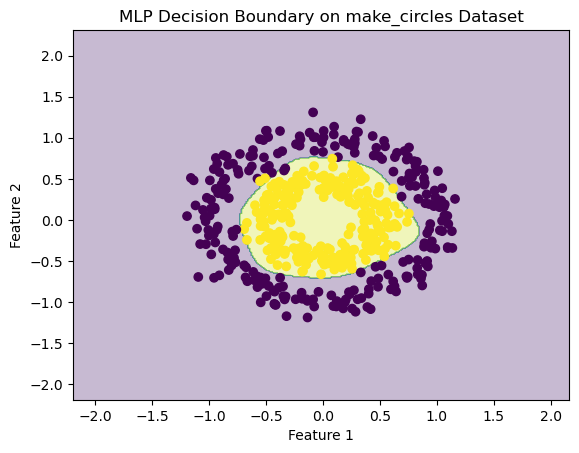

In [ ]:
# Generate dataset
X, y = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def dsigmoid(y):
    return y * (1 - y)

# Initialize MLP
np.random.seed(42)
W1 = np.random.randn(2, 8)
b1 = np.zeros((1, 8))
W2 = np.random.randn(8, 1)
b2 = np.zeros((1, 1))

lr = 0.01
epochs = 200000

# Train MLP
for _ in range(epochs):
    z1 = X_train @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    y_pred = sigmoid(z2)

    d_out = y_pred - y_train
    d_hidden = d_out @ W2.T * dsigmoid(a1)

    W2 -= lr * (a1.T @ d_out) / len(X_train)
    b2 -= lr * np.mean(d_out, axis=0, keepdims=True)
    W1 -= lr * (X_train.T @ d_hidden) / len(X_train)
    b1 -= lr * np.mean(d_hidden, axis=0, keepdims=True)

# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

grid = np.c_[xx.ravel(), yy.ravel()]
grid = scaler.transform(grid)

# Predict on grid
h = sigmoid(grid @ W1 + b1)
Z = sigmoid(h @ W2 + b2)
Z = (Z >= 0.5).astype(int)
Z = Z.reshape(xx.shape)

# Plot
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:, 0], X[:, 1], c=y.flatten())
plt.title("MLP Decision Boundary on make_circles Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
